In [1]:
from data.loader import load_data, encode_categoricals
from data.preparation import add_derived_columns, filter_crops
from config import CampaignPaths, get_campaign_paths
from column_taxonomy import SOBOL_FEATURES, CATEGORICAL_FEATURES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("analysis.pipeline")

In [2]:
# 1. Load data & preview
CAMPAIGN_NAME = "sobol_training_1_n2048"
campaign = get_campaign_paths(CAMPAIGN_NAME)

num_features = [feat for feat in SOBOL_FEATURES if feat not in CATEGORICAL_FEATURES]
cat_features = [feat for feat in SOBOL_FEATURES if feat in CATEGORICAL_FEATURES]

df = load_data(campaign.raw_meta)
n_rows_bf, n_cols_bf = df.shape
df = add_derived_columns(df)
df, _ = filter_crops(df, excluded_crops=["rape"])
df, _ = encode_categoricals(df, features=SOBOL_FEATURES, method="sklearn")
n_rows_pr, n_cols_pr = df.shape
logger.info(f"✅ Data loaded & prepared:")
logger.info(f"Raw data:  {n_rows_bf} rows x {n_cols_bf} columns")
logger.info(f"Prep data: {n_rows_pr} rows x {n_cols_pr} columns")

2026-04-10 15:52:39 [INFO] data.loader — 📂 Loading meta_table_sobol_training_1_n2048.parquet  (format: parquet, engine: pandas)
2026-04-10 15:52:39 [INFO] data.loader — ✅ Loaded: 81800 rows × 128 columns
2026-04-10 15:52:39 [INFO] data.preparation — Adding derived columns
2026-04-10 15:52:40 [INFO] data.preparation —    ✓ Added 'Harvest_Year_Absolute' (normalised per SimID)
2026-04-10 15:52:40 [INFO] data.preparation —    ✓ Added 'Rotation' flag (0 / 81800 cycles in rotation)
2026-04-10 15:52:40 [INFO] data.preparation —    ✓ Filled 81800 NaN values in 'rot_id' with 'monoculture'
2026-04-10 15:52:40 [INFO] data.preparation — Filtering crops: ['rape']
2026-04-10 15:52:40 [INFO] data.loader — 🏷️  Encoding 3 categorical features (method='sklearn', fit=True)
2026-04-10 15:52:40 [INFO] data.loader —    • main_crop                 → int (LabelEncoder fitted, 2 classes)
2026-04-10 15:52:40 [INFO] data.loader —    • period                    → int (LabelEncoder fitted, 1 classes)
2026-04-10 15

# Distribution générale des outputs clés

In [ ]:
df.groupby('SimID')['yield_AF'].mean().describe()

count    2044.000000
mean        4.933752
std         2.600527
min         0.000000
25%         3.055889
50%         5.298552
75%         6.952778
max        10.412651
Name: yield_AF, dtype: float64

In [4]:
df[df['Cycle_Nb'] == df.groupby('SimID')['Cycle_Nb'].transform('max')]['tree_height_AF'].describe()

count    2045.000000
mean        9.842434
std        10.584503
min         0.750016
25%         0.768220
50%         3.522359
75%        18.040447
max        41.063076
Name: tree_height_AF, dtype: float64

In [5]:
df[df['Cycle_Nb'] == df.groupby('SimID')['Cycle_Nb'].transform('max')]['carbonStem_AF'].describe()

count    2045.000000
mean      288.882470
std       598.196176
min         0.007789
25%         0.020308
50%         3.433525
75%       289.707518
max      4219.666794
Name: carbonStem_AF, dtype: float64

# Diagnostic des simulations arboricoles défaillantes

In [6]:
# 2.1 Tree failures

# --- 1a. Hauteur finale par SimID ---
last_cycle = df.loc[df.groupby('SimID')['Cycle_Nb'].idxmax(),
                    [f for f in df.columns]].copy()

TREE_FAIL_THRESHOLD = 1.0  # kg.C / tree
last_cycle['tree_failed'] = last_cycle['carbonStem_AF'] < TREE_FAIL_THRESHOLD

print("=== Arbres défaillants ===")
print(last_cycle['tree_failed'].value_counts())
print(f"\nTaux d'échec : {last_cycle['tree_failed'].mean():.1%}")

# --- 1b. Features NUMERIQUES : moyenne par groupe ---

print("\n=== Features numériques : défaillants vs OK ===")
comp_num = last_cycle.groupby('tree_failed')[num_features].mean().T.round(3)
comp_num.columns = ['OK (False)', 'Défaillant (True)']
comp_num['delta'] = comp_num['Défaillant (True)'] - comp_num['OK (False)']
print(comp_num)

# --- 1c. Features CATEGORIELLES : fréquences par groupe ---
print("\n=== Features catégorielles : distribution par groupe ===")
for col in cat_features:
    print(f"\n  [{col}]")
    ct = pd.crosstab(last_cycle['tree_failed'], last_cycle[col], normalize='index').round(3)
    print(ct)

=== Arbres défaillants ===
tree_failed
False    1107
True      938
Name: count, dtype: int64

Taux d'échec : 45.9%

=== Features numériques : défaillants vs OK ===
                  OK (False)  Défaillant (True)  delta
plotWidth             13.596             14.177  0.581
plotHeight            10.008             10.309  0.301
strip_width            3.000              3.000  0.000
northOrientation      90.000             90.000  0.000
Rotation               0.000              0.000  0.000
soilDepth              4.996              5.007  0.011
sand                  34.779             31.509 -3.270
clay                  31.982             35.047  3.065
stone                 13.881             16.319  2.438
waterTable             0.503              0.497 -0.006
w_peak_doy            60.000             60.000  0.000
w_amp                  4.000              4.000  0.000
w_mean                -7.000             -7.000  0.000
latitude              45.959             46.052  0.093
longitude  

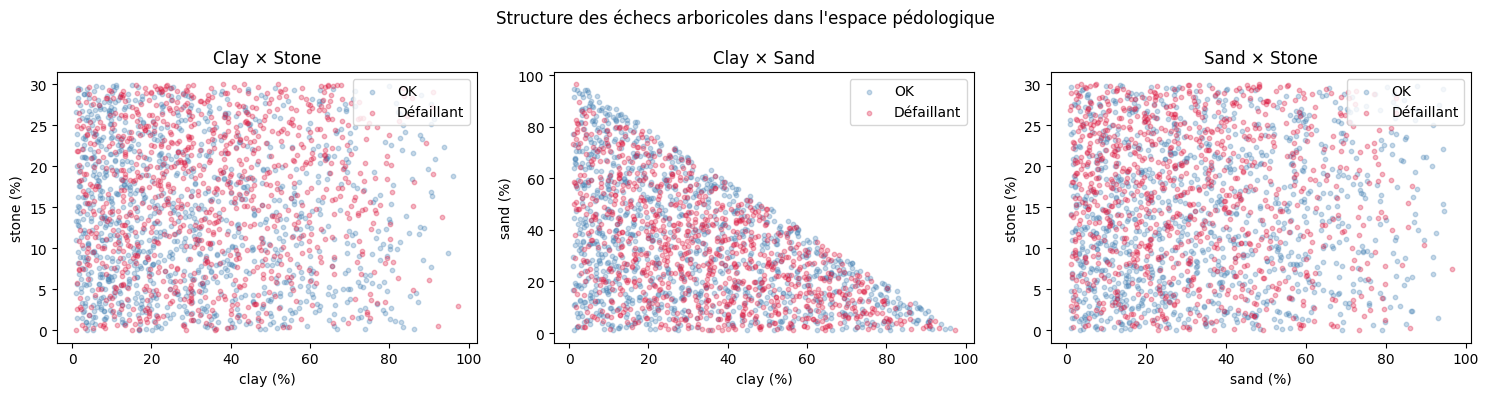

In [7]:
# --- 2a. Scatter clay × stone coloré par tree_failed ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Clay vs Stone
axes[0].scatter(
    last_cycle.loc[last_cycle['tree_failed']==False, 'clay'],
    last_cycle.loc[last_cycle['tree_failed']==False, 'stone'],
    alpha=0.3, s=10, label='OK', color='steelblue'
)
axes[0].scatter(
    last_cycle.loc[last_cycle['tree_failed']==True, 'clay'],
    last_cycle.loc[last_cycle['tree_failed']==True, 'stone'],
    alpha=0.3, s=10, label='Défaillant', color='crimson'
)
axes[0].set_xlabel('clay (%)'); axes[0].set_ylabel('stone (%)')
axes[0].set_title('Clay × Stone'); axes[0].legend()

# Clay vs Sand
axes[1].scatter(
    last_cycle.loc[last_cycle['tree_failed']==False, 'clay'],
    last_cycle.loc[last_cycle['tree_failed']==False, 'sand'],
    alpha=0.3, s=10, label='OK', color='steelblue'
)
axes[1].scatter(
    last_cycle.loc[last_cycle['tree_failed']==True, 'clay'],
    last_cycle.loc[last_cycle['tree_failed']==True, 'sand'],
    alpha=0.3, s=10, label='Défaillant', color='crimson'
)
axes[1].set_xlabel('clay (%)'); axes[1].set_ylabel('sand (%)')
axes[1].set_title('Clay × Sand'); axes[1].legend()

# Sand vs Stone
axes[2].scatter(
    last_cycle.loc[last_cycle['tree_failed']==False, 'sand'],
    last_cycle.loc[last_cycle['tree_failed']==False, 'stone'],
    alpha=0.3, s=10, label='OK', color='steelblue'
)
axes[2].scatter(
    last_cycle.loc[last_cycle['tree_failed']==True, 'sand'],
    last_cycle.loc[last_cycle['tree_failed']==True, 'stone'],
    alpha=0.3, s=10, label='Défaillant', color='crimson'
)
axes[2].set_xlabel('sand (%)'); axes[2].set_ylabel('stone (%)')
axes[2].set_title('Sand × Stone'); axes[2].legend()

plt.suptitle("Structure des échecs arboricoles dans l'espace pédologique", fontsize=12)
plt.tight_layout()
plt.savefig("tree_fail_soil_space.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
feature_cols = SOBOL_FEATURES

X_tree = last_cycle[feature_cols].copy()
y_tree = last_cycle['tree_failed'].astype(int)

# Masque des lignes complètes
mask = X_tree.notna().all(axis=1)
X_tree, y_tree = X_tree[mask], y_tree[mask]

clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)
clf.fit(X_tree, y_tree)

print(f"Accuracy : {clf.score(X_tree, y_tree):.3f}")
print(f"\n=== Règles de décision ===")
print(export_text(clf, feature_names=feature_cols))

print("\n=== Importances des features ===")
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.round(4))

Accuracy : 0.667

=== Règles de décision ===
|--- main_crop <= 0.50
|   |--- stone <= 12.52
|   |   |--- longitude <= 0.47
|   |   |   |--- latitude <= 43.19
|   |   |   |   |--- class: 0
|   |   |   |--- latitude >  43.19
|   |   |   |   |--- class: 0
|   |   |--- longitude >  0.47
|   |   |   |--- latitude <= 44.06
|   |   |   |   |--- class: 0
|   |   |   |--- latitude >  44.06
|   |   |   |   |--- class: 0
|   |--- stone >  12.52
|   |   |--- clay <= 12.88
|   |   |   |--- latitude <= 43.15
|   |   |   |   |--- class: 1
|   |   |   |--- latitude >  43.15
|   |   |   |   |--- class: 0
|   |   |--- clay >  12.88
|   |   |   |--- longitude <= 0.10
|   |   |   |   |--- class: 1
|   |   |   |--- longitude >  0.10
|   |   |   |   |--- class: 0
|--- main_crop >  0.50
|   |--- plotHeight <= 5.50
|   |   |--- latitude <= 45.39
|   |   |   |--- longitude <= 0.72
|   |   |   |   |--- class: 0
|   |   |   |--- longitude >  0.72
|   |   |   |   |--- class: 0
|   |   |--- latitude >  45.39
|   |

=== Corrélations Spearman (niveau SimID) ===
              mean_yield  final_height  final_carbon
mean_yield         1.000         0.314         0.324
final_height       0.314         1.000         0.985
final_carbon       0.324         0.985         1.000


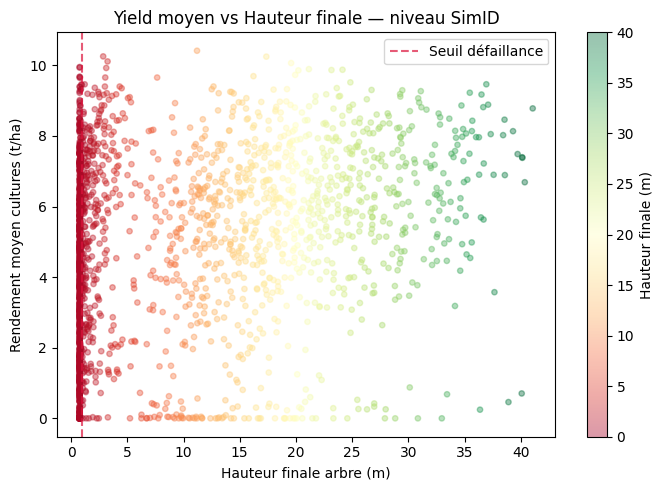

In [9]:
# Au niveau SimID : est-ce que les arbres qui poussent pénalisent la culture ?
sim_summary = df.groupby('SimID').agg(
    mean_yield   = ('yield_AF', 'mean'),
    final_height = ('tree_height_AF', 'last'),
    final_carbon = ('carbonStem_AF', 'last')
).reset_index()

print("=== Corrélations Spearman (niveau SimID) ===")
corr = sim_summary[['mean_yield', 'final_height', 'final_carbon']].corr(method='spearman')
print(corr.round(3))

# Scatter yield moyen vs hauteur finale
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    sim_summary['final_height'],
    sim_summary['mean_yield'],
    alpha=0.4, s=15, c=sim_summary['final_height'],
    cmap='RdYlGn', norm=mcolors.Normalize(vmin=0, vmax=40)
)
plt.colorbar(sc, ax=ax, label='Hauteur finale (m)')
ax.set_xlabel('Hauteur finale arbre (m)')
ax.set_ylabel('Rendement moyen cultures (t/ha)')
ax.set_title('Yield moyen vs Hauteur finale — niveau SimID')
ax.axvline(x=1.0, color='crimson', linestyle='--', alpha=0.7, label='Seuil défaillance')
ax.legend()
plt.tight_layout()
plt.savefig("yield_vs_height_simid.png", dpi=150, bbox_inches='tight')
plt.show()

# Diagnostic des simulations culturales défaillantes

In [10]:
# --- Paramètres ---
YIELD_FAIL_THRESHOLD = 0.5  # t/ha

plan_snapshot = df[SOBOL_FEATURES + ['SimID']].drop_duplicates('SimID')

sim_yield = df.groupby('SimID').agg(
    n_cycles          = ('yield_AF', 'count'),
    mean_yield_AF     = ('yield_AF', 'mean'),
    zero_rate_AF      = ('yield_AF', lambda x: (x < YIELD_FAIL_THRESHOLD).sum() / len(x)),
    mean_yield_TA     = ('yield_TA', 'mean'),
    zero_rate_TA      = ('yield_TA', lambda x: (x < YIELD_FAIL_THRESHOLD).sum() / len(x)),
).reset_index()

sim_yield = sim_yield.merge(plan_snapshot, on='SimID', how='left')

# --- Flags d'échec ---
FAIL_RATE_THRESHOLD = 0.5  # SimID "défaillant" si >50% de cycles à yield < seuil

sim_yield['yield_AF_failed'] = sim_yield['zero_rate_AF'] > FAIL_RATE_THRESHOLD
sim_yield['yield_TA_failed'] = sim_yield['zero_rate_TA'] > FAIL_RATE_THRESHOLD

print("=" * 55)
print("=== Échecs rendement AF ===")
print(sim_yield['yield_AF_failed'].value_counts())
print(f"Taux d'échec AF : {sim_yield['yield_AF_failed'].mean():.1%}")

print("\n=== Échecs rendement TA ===")
print(sim_yield['yield_TA_failed'].value_counts())
print(f"Taux d'échec TA : {sim_yield['yield_TA_failed'].mean():.1%}")

# --- Matrice de co-occurrence AF × TA ---
print("\n=== Co-occurrence des échecs AF et TA ===")
print(pd.crosstab(
    sim_yield['yield_AF_failed'].map({True: 'AF_failed', False: 'AF_ok'}),
    sim_yield['yield_TA_failed'].map({True: 'TA_failed', False: 'TA_ok'}),
    margins=True
))

# --- Comparaison features numériques : OK vs défaillants ---
def compare_features(df_sim, fail_col, num_cols):
    comp = df_sim.groupby(fail_col)[num_cols].mean().T.round(3)
    comp.columns = ['OK (False)', 'Défaillant (True)']
    comp['delta'] = comp['Défaillant (True)'] - comp['OK (False)']
    comp['delta_%'] = (comp['delta'] / comp['OK (False)'].abs() * 100).round(1)
    return comp.sort_values('delta', key=abs, ascending=False)

print("\n=== Features numériques — Échec yield_AF ===")
print(compare_features(sim_yield, 'yield_AF_failed', num_features))

print("\n=== Features numériques — Échec yield_TA ===")
print(compare_features(sim_yield, 'yield_TA_failed', num_features))

# --- Distribution par main_crop ---
print("\n=== main_crop — Échec yield_AF ===")
print(pd.crosstab(sim_yield['yield_AF_failed'], sim_yield['main_crop'], normalize='index').round(3))

print("\n=== main_crop — Échec yield_TA ===")
print(pd.crosstab(sim_yield['yield_TA_failed'], sim_yield['main_crop'], normalize='index').round(3))

# --- Arbres de décision AF et TA ---
def fit_decision_tree(df_sim, fail_col, feature_cols, depth=4):
    X = df_sim[feature_cols].copy()
    y = df_sim[fail_col].astype(int)
    mask = X.notna().all(axis=1)
    X, y = X[mask], y[mask]
    clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=20, random_state=42)
    clf.fit(X, y)
    print(f"  Accuracy : {clf.score(X, y):.3f}")
    print(export_text(clf, feature_names=feature_cols))
    imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("  Importances :")
    print(imp[imp > 0].round(4))
    return clf

print("\n" + "=" * 55)
print("=== Arbre de décision — Échec yield_AF ===")
clf_AF = fit_decision_tree(sim_yield, 'yield_AF_failed', num_features)

print("\n=== Arbre de décision — Échec yield_TA ===")
clf_TA = fit_decision_tree(sim_yield, 'yield_TA_failed', num_features)

# --- Quadrant : 4 cas possibles AF × TA ---
print("\n=== Analyse par quadrant AF × TA ===")
sim_yield['quadrant'] = 'unknown'
sim_yield.loc[~sim_yield['yield_AF_failed'] & ~sim_yield['yield_TA_failed'], 'quadrant'] = 'AF_ok × TA_ok'
sim_yield.loc[ sim_yield['yield_AF_failed'] & ~sim_yield['yield_TA_failed'], 'quadrant'] = 'AF_fail × TA_ok'
sim_yield.loc[~sim_yield['yield_AF_failed'] &  sim_yield['yield_TA_failed'], 'quadrant'] = 'AF_ok × TA_fail'
sim_yield.loc[ sim_yield['yield_AF_failed'] &  sim_yield['yield_TA_failed'], 'quadrant'] = 'AF_fail × TA_fail'

print(sim_yield['quadrant'].value_counts())
print("\nFeatures moyennes par quadrant :")
print(sim_yield.groupby('quadrant')[num_features].mean().T.round(3))

=== Échecs rendement AF ===
yield_AF_failed
False    1753
True      292
Name: count, dtype: int64
Taux d'échec AF : 14.3%

=== Échecs rendement TA ===
yield_TA_failed
False    1749
True      296
Name: count, dtype: int64
Taux d'échec TA : 14.5%

=== Co-occurrence des échecs AF et TA ===
yield_TA_failed  TA_failed  TA_ok   All
yield_AF_failed                        
AF_failed              251     41   292
AF_ok                   45   1708  1753
All                    296   1749  2045

=== Features numériques — Échec yield_AF ===
                  OK (False)  Défaillant (True)  delta  delta_%
clay                  32.852             36.606  3.754     11.4
latitude              46.421             43.487 -2.934     -6.3
sand                  33.640             31.112 -2.528     -7.5
longitude              1.918              4.301  2.383    124.2
stone                 14.765             16.402  1.637     11.1
plotWidth             13.826             14.082  0.256      1.9
soilDepth         

In [11]:
# Merge des deux critères sur SimID
check = sim_yield[['SimID', 'yield_AF_failed', 'yield_TA_failed']].merge(
    last_cycle[['SimID', 'tree_failed']],
    on='SimID', how='inner'
)

# Population nominale rendement seul (critère actuel)
mask_yield_ok = ~check['yield_AF_failed'] & ~check['yield_TA_failed']

# Sous-ensemble : nominaux rendement MAIS tree_failed
mask_problematic = mask_yield_ok & check['tree_failed']

print(f"Nominaux (yield seul)            : {mask_yield_ok.sum()}")
print(f"Dont tree_failed                 : {mask_problematic.sum()}")
print(f"Part sur nominaux yield          : {mask_problematic.sum() / mask_yield_ok.sum():.1%}")
print(f"Part sur total SimIDs            : {mask_problematic.sum() / len(check):.1%}")

Nominaux (yield seul)            : 1708
Dont tree_failed                 : 754
Part sur nominaux yield          : 44.1%
Part sur total SimIDs            : 36.9%


In [12]:
check['population'] = 'unknown'

check.loc[
     mask_yield_ok & ~check['tree_failed'], 'population'
] = 'yield_ok × tree_ok'

check.loc[
     mask_yield_ok & check['tree_failed'], 'population'
] = 'yield_ok × tree_failed'

check.loc[
    ~mask_yield_ok & ~check['tree_failed'], 'population'
] = 'yield_fail × tree_ok'

check.loc[
    ~mask_yield_ok & check['tree_failed'], 'population'
] = 'yield_fail × tree_failed'

print(check['population'].value_counts())
print((check['population'].value_counts() / len(check) * 100).round(1))

population
yield_ok × tree_ok          954
yield_ok × tree_failed      754
yield_fail × tree_failed    184
yield_fail × tree_ok        153
Name: count, dtype: int64
population
yield_ok × tree_ok          46.7
yield_ok × tree_failed      36.9
yield_fail × tree_failed     9.0
yield_fail × tree_ok         7.5
Name: count, dtype: float64
